# pytorch化的实现

## 公共执行

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)

block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


**尝试训练一个更深的神经网络**

## 基本网络模块定义

In [3]:
# # pytorch的标准module实现中并没有 self.out，这里是为了后续可视化容易显示变量结果，因此对于每个类，都给了个 self.out 属性
class Linear:
  """https://docs.pytorch.org/docs/2.13/generated/torch.nn.Linear.html
  """
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
  """https://docs.pytorch.org/docs/2.13/generated/torch.nn.BatchNorm1d.html
  """
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True                                               # 并没有体现在初始化的参数中，是后续实例化后直接调用修改
    # https://github.com/pytorch/pytorch/blob/v2.13.0/torch/nn/modules/batchnorm.py#L187 pytorch里的实现，也确实有training这个bool值
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)                                 # 这里用的是方差，不是标准差了，完全和论文保持一致了       
  
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      xmean = x.mean(0, keepdim=True) # batch mean
      xvar = x.var(0, keepdim=True) # batch variance

      # update the buffers
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta                         
   
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]  # 对应pytorch里BN层的weight和bias，不会返回running_mean和running_var，后两个是滑动平均算的，不需要依靠梯度下降算法和反向传播进行计算

class Tanh:
  """https://docs.pytorch.org/docs/2.13/generated/torch.nn.Tanh.html
  """
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

In [4]:
g = torch.Generator().manual_seed(2147483647) 
a = Linear(10, 20)
a.weight.shape[0]

10

# 不加BN实现

## 网络定义

In [5]:
def run(gain, normal_run = False):
    n_embd = 10 # the dimensionality of the character embedding vectors
    n_hidden = 100 # the number of neurons in the hidden layer of the MLP
    g = torch.Generator().manual_seed(2147483647) # for reproducibility
    
    C = torch.randn((vocab_size, n_embd),            generator=g)
    layers = [
      Linear(n_embd * block_size, n_hidden), Tanh(),
      Linear(           n_hidden, n_hidden), Tanh(),
      Linear(           n_hidden, n_hidden), Tanh(),
      Linear(           n_hidden, n_hidden), Tanh(),
      Linear(           n_hidden, n_hidden), Tanh(),
      Linear(           n_hidden, vocab_size),
    ]
    with torch.no_grad():
      # last layer: make less confident  
      # logits = h @ W2 + b2  最后一层线性层的结果会被作为logits(之前就是希望logits全部为0/全部为一个相同的数字，这样初始化时候输出的结果对每个类别都是公平的)，所以这里会对W缩小一点，防止softmax部分过于自信  
      # 详见 4_MLP2_makemore.ipynb中 随机初始化的坏处 前面一个cell的描述，及这个部分的内容
      layers[-1].weight *= 0.1
        
      # all other layers: apply gain
      # 其他所有层，由于用的是tanh() 所以对应 kaiming init里的 5/3  详见 4_MLP2_makemore.ipynb中关于 kaiming初始化部分
      # https://docs.pytorch.org/docs/2.12/nn.init.html#torch.nn.init.kaiming_normal_
      for layer in layers[:-1]:
        if isinstance(layer, Linear):
          # self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
          # layer.weight *= 5/3
          # 上面两个步骤组合 =  layer.weight *= 5/3/(layer.weight.shape[0]**0.5) 
          # layer.weight *= 1
          layer.weight *= gain    
    parameters = [C] + [p for layer in layers for p in layer.parameters()]
    print(sum(p.nelement() for p in parameters)) # number of parameters in total
    for p in parameters:
      p.requires_grad = True  # 明确告知pytorch这些参数需要求梯度
    
    # same optimization as last time
    max_steps = 200000
    batch_size = 32
    lossi = []
    # ud = []
    
    for i in range(max_steps): 
      # minibatch construct
      ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
      Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
      # forward pass
      emb = C[Xb] # embed the characters into vectors
      x = emb.view(emb.shape[0], -1) # concatenate the vectors
      for layer in layers:
        x = layer(x)
      loss = F.cross_entropy(x, Yb) # loss function
      # backward pass
      for layer in layers:
        layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
      for p in parameters:
        p.grad = None
      loss.backward()
      # update
      lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
      for p in parameters:
        p.data += -lr * p.grad
      # track stats
      if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
      lossi.append(loss.log10().item())

      # 只运行1次，就break，查看初始化状态；运行1000次看状态，看反向传播不同层的梯度更新速度
      if normal_run:
          if i >= 1000:
              break
      else:
          break # AFTER_DEBUG: would take out obviously to run full optimization
    return layers,parameters

只执行了一次前向和反向，相当于此时模型参数虽然更新了，但是还没有计算损失，因此，反映的是利用初始化状态来计算梯度的情况

In [7]:
def plot_out(layers, layer_instance = Tanh):
    plt.figure(figsize=(20, 4)) # width and height of the plot
    legends = []
    for i, layer in enumerate(layers[:-1]): # note: exclude the output layer 不看logits那层，那层没有tanh处理
      if isinstance(layer, layer_instance):
        t = layer.out
        # 这里看的就是经过tanh之后的激活值， 看了mean和std，观察分布； 看(t.abs() > 0.97) 尾部区域的比例， 注意 这里t = tanh(x), t>0.97, x>|2|
        # 可以去看 4_MLP2_makemore 里 交互式tanh的图像
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density=True) 
        # density: If True, the result is the value of the probability density function over the bins, normalized such that the integral over the range of the bins is 1.
        # Returns:
        # hist (Tensor): 1D Tensor containing the values of the histogram.  第1个返回值 hist 每个 bin（区间）中的频数/密度值 可以作为绘图的y值
        # bin_edges(Tensor): 1D Tensor containing the edges of the histogram bins. 第2个返回值 bin_edges bin 的边界值（比 bin 数量多1） 可以作为绘图的x值
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer{i}_{layer.__class__.__name__}')
    plt.legend(legends);
    plt.title('activation distribution')

def plot_out_grad(layers, layer_instance = Tanh):
    plt.figure(figsize=(20, 4))
    legends = []
    for i, layer in enumerate(layers[:-1]): 
      if isinstance(layer, layer_instance):
        t = layer.out.grad
        print('layer %d (%10s): mean %+.2f, std %.2f' % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density=True) 
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer{i}_{layer.__class__.__name__}')
    plt.legend(legends);
    plt.title('activation distribution')

def plot_w_grad(parameters):
    plt.figure(figsize=(20, 4)) # width and height of the plot
    legends = []
    for i,p in enumerate(parameters):
      t = p.grad
      # 只看线性层的W权重，不看b权重
      if p.ndim == 2:
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'{i} {tuple(p.shape)}')
    plt.legend(legends)
    plt.title('weights gradient distribution');

## 激活值(梯度)可视化结果讨论

In [8]:
layers, _ = run(gain = 5/3)

46497
      0/ 200000: 3.3106


In [9]:
layers[0].__class__.__name__, layers[1].__class__.__name__, layers[-1].__class__.__name__
# .__class__.__name__  就是返回类名称

('Linear', 'Tanh', 'Linear')

layer 1 (      Tanh): mean +0.01, std 0.76, saturated: 20.34%
layer 3 (      Tanh): mean +0.02, std 0.69, saturated: 8.91%
layer 5 (      Tanh): mean -0.03, std 0.67, saturated: 7.53%
layer 7 (      Tanh): mean -0.02, std 0.66, saturated: 6.16%
layer 9 (      Tanh): mean -0.00, std 0.65, saturated: 5.06%


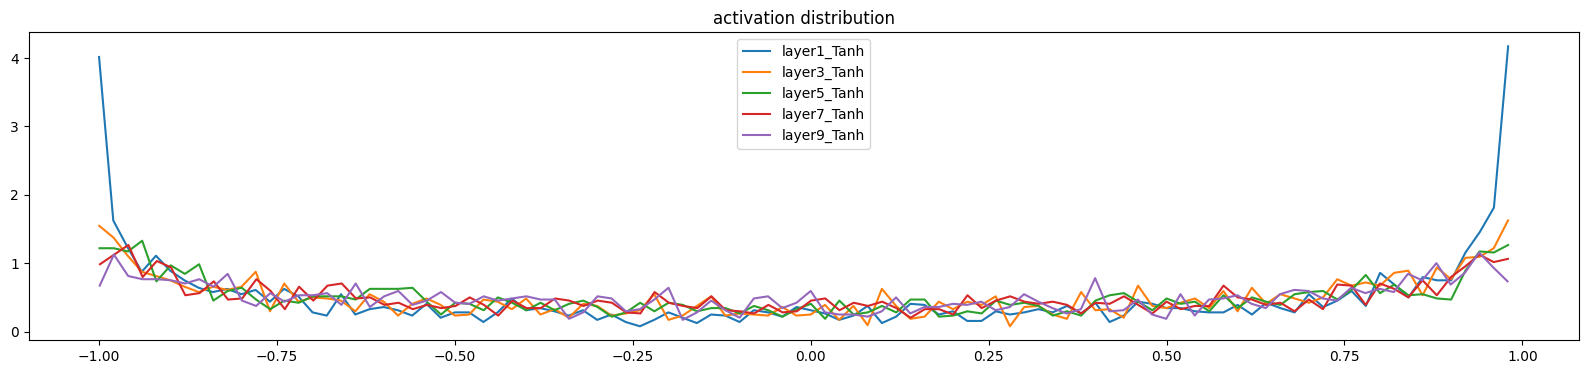

In [10]:
# visualize histograms
# layer.weight *= 5/3 的结果
plot_out(layers)

从上图中可以发现：
1. 除了第一层的 `tanh饱和率` 是20%多，其余几层就很稳定
2. 同时除了第一层的 `std` 是0.76，后面几层也是稳定在0.65左右

---

对比下面的 `layer.weight *= 1` Tanh层的结果 可以看到：
+ 之前所说的直接`self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5`是针对纯线性层的，可以保证线性层的输出符合标准正态分布
+ 但是这里是`tanh`层, 而`tanh`层本身是一种压缩层，会导致输入变小，
  + `layer.weight *= 1`里方差基本稳定在 0.54
  + 因此需要额外添加一个增益，抵消这个压缩带来的影响，因此，乘以`5/3`, 可以让方差大一些，上面方差就稳定在 0.73 左右了
  + 所以这个`5/3`是个经验值, 将`tanh`饱和度控制在一定范围的同时增大方差

46497
      0/ 200000: 3.3086
layer 1 (      Tanh): mean +0.01, std 0.62, saturated: 3.16%
layer 3 (      Tanh): mean -0.01, std 0.47, saturated: 0.00%
layer 5 (      Tanh): mean +0.02, std 0.41, saturated: 0.00%
layer 7 (      Tanh): mean -0.00, std 0.37, saturated: 0.00%
layer 9 (      Tanh): mean +0.01, std 0.32, saturated: 0.00%


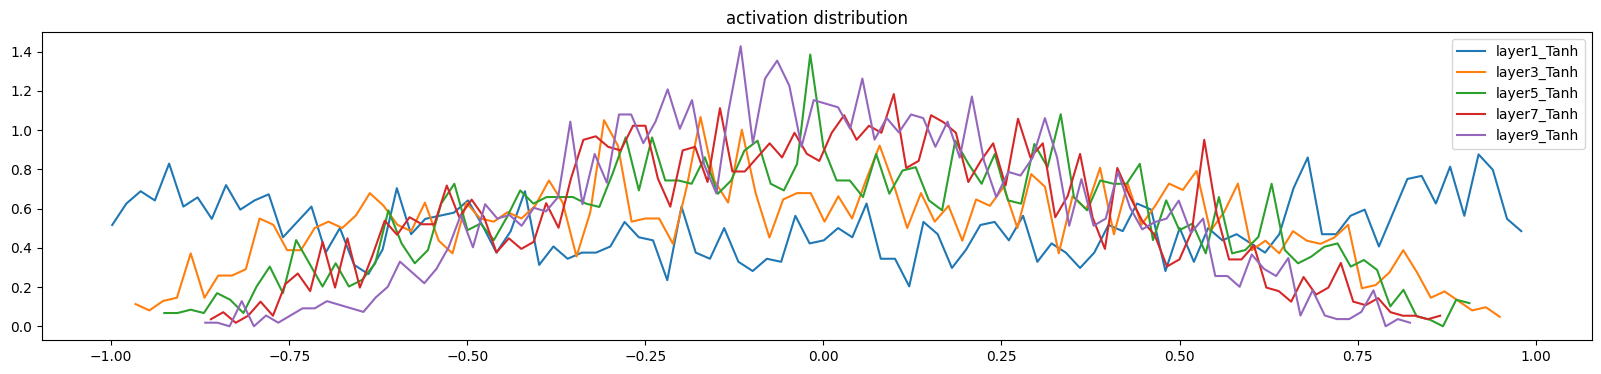

In [11]:
layers, _ = run(gain = 1) # gain = 1
# layer.weight *= 1 Tanh层的结果
plot_out(layers)

如果不对`layer.weight`使用`5/3`的增益，可以看到：
+ `std`在减小
+ `saturated`也在不停的减小，减小到为0了

---

按照之前的讨论，如果网络中只有线性层， 则`self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5`这种方案可以保证输出标准正态分布

但是这里不仅有线性层，这里还有`tanh`层，所以这里需要添加`5/3`的增益的原因在于： `tanh`本身是一种压缩函数，需要一定的增益，才可以把被缩小的输入给均衡一下，变大~


46497
      0/ 200000: 3.2913
layer 1 (      Tanh): mean +0.00, std 0.00
layer 3 (      Tanh): mean -0.00, std 0.00
layer 5 (      Tanh): mean +0.00, std 0.00
layer 7 (      Tanh): mean -0.00, std 0.00
layer 9 (      Tanh): mean -0.00, std 0.00


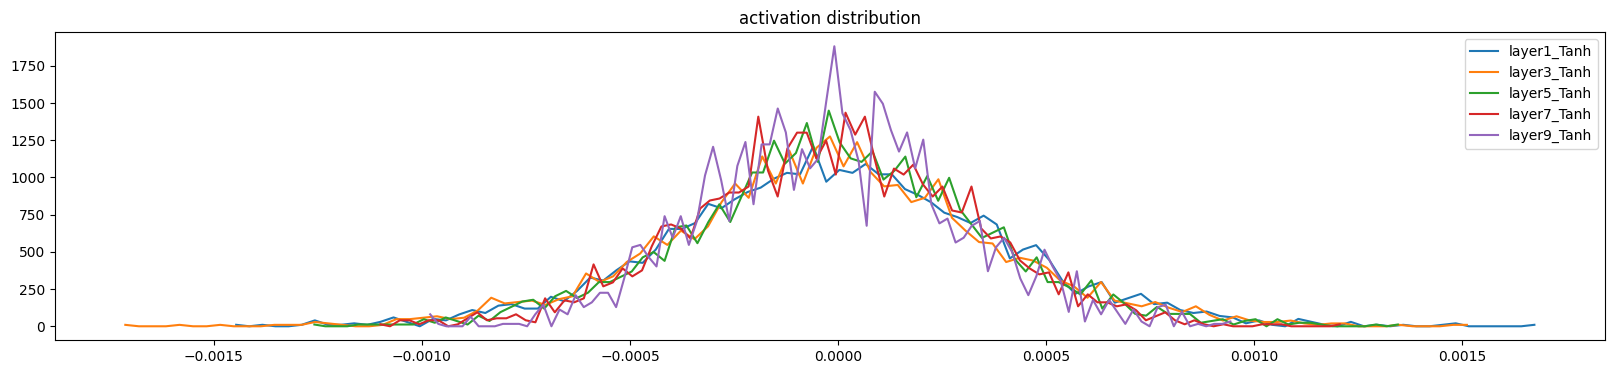

In [16]:
# 也可以看看梯度的情况
layers, _ = run(gain = 5/3) # gain = 5/3   gain = 0.5 
plot_out_grad(layers)

可以看到, `gain = 5/3`时：
+ 梯度值的范围基本都是 [-0.02, 0.02]这个区间，大部分集中在0附近这个区间
+ 整体均值为0，方差为0
+ 可以看到至少在这个网络结构里，**每层都能保持大致相同的梯度水平**，梯度即没有衰减(`shrinking`)，也没有爆炸(`exploding`)

`gain = 0.5`时：
+ 梯度值的范围基本都是 [-0.0075, 0.0075]这个区间，大部分集中在0附近这个区间
+ 其余同上

所以**增益会影响 激活值 和 梯度 的大小**
+ 增益太小，激活值就会小，→ `tanh`的饱和率会下降，但是遵从的正态分布的`std`会减小(比如： 0.3等，比1要小很多)，同时，梯度的数值也会减小，比如：[-0.0075, 0.0075]这个区间
+ 增益太大，激活值就会大，→ `tanh`的饱和率会上升，但是遵从的正态分布的`std`会增大(比如： 0.7, 0.8等，会相对靠近1)，同时，梯度的数值也会更大，比如：[-0.03, 0.03]这个区间
+ 因此，需要权衡 `tanh`的饱和率以及正态分布的`std`，以及梯度的数值范围，所以`5/3`是个比较合适的经验值
  + `tanh`的饱和率维持在10%左右，
  + `std`在0.7左右，
  + `梯度的数值范围`在[-0.02, 0.02]这个区间

46497
      0/ 200000: 3.2961
layer 1 (      Tanh): mean -0.00, std 0.00
layer 3 (      Tanh): mean +0.00, std 0.00
layer 5 (      Tanh): mean -0.00, std 0.00
layer 7 (      Tanh): mean -0.00, std 0.00
layer 9 (      Tanh): mean +0.00, std 0.00


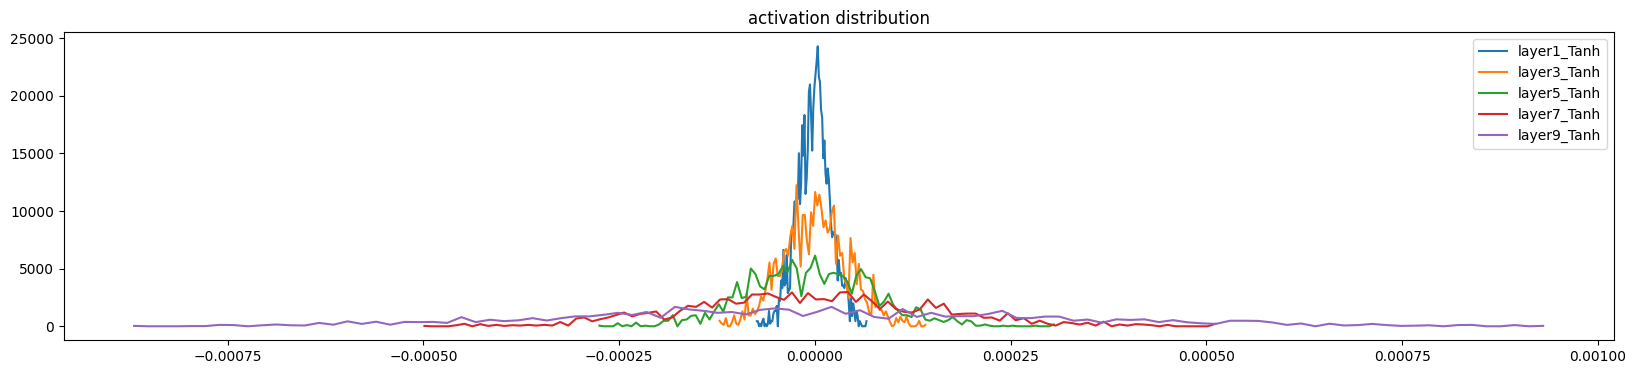

In [17]:
layers, _ = run(gain = 0.5) # gain = 1   gain = 0.5 
plot_out_grad(layers)

上图可以看到，当`gain`太小的时候，每层的梯度分布差距就很大，从第一层开始，梯度为0的很多，之后梯度为0的逐渐减少

下图可以看到，当`gain`太大的时候, 层数越深，激活值的梯度开始不对称，同时其统计特性还在不断变化，没有显示出明显的收敛趋势

以上结果可以看出：**如果没有BN，那么就要很小心的去设置gain参数**， 才能获得理想的前向传播激活值和反向的梯度值

46497
      0/ 200000: 3.2993
layer 1 (      Tanh): mean -0.000027, std 9.817913e-04
layer 3 (      Tanh): mean +0.000001, std 7.581678e-04
layer 5 (      Tanh): mean -0.000001, std 5.644087e-04
layer 7 (      Tanh): mean +0.000014, std 4.222544e-04
layer 9 (      Tanh): mean +0.000006, std 3.015743e-04


Text(0.5, 1.0, 'activation distribution')

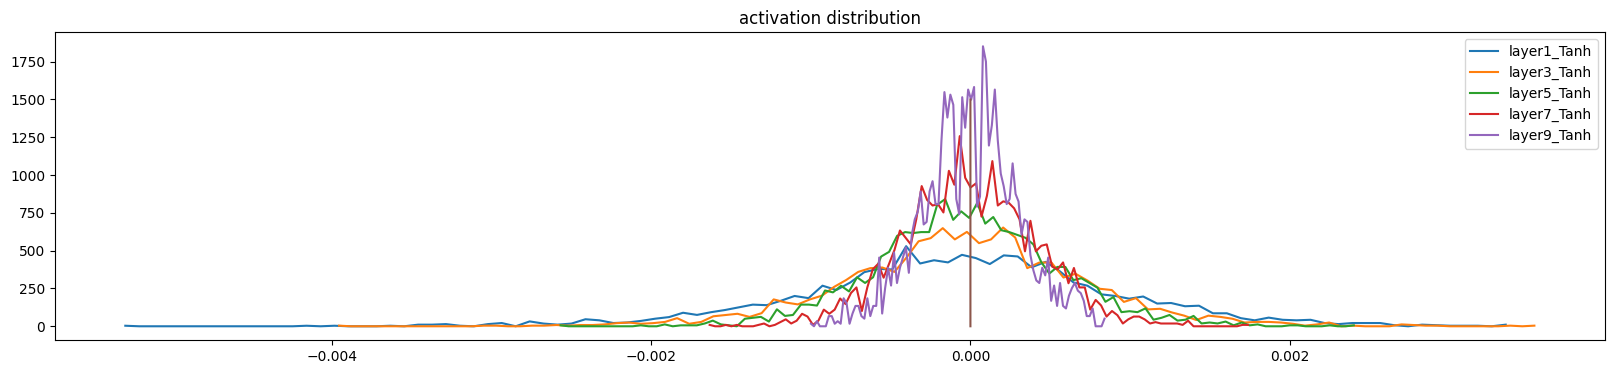

In [22]:
layers, _ = run(gain = 3) # gain = 1
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]): 
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True) 
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer{i}_{layer.__class__.__name__}')

y = list(range(1500))
x = [0]*len(y)
plt.plot(x,y)
plt.legend(legends);
plt.title('activation distribution')

## 不要tanh层的网络的可视化结果

In [25]:
from utils_4 import run_without_tanh
layers = run_without_tanh(5/3, vocab_size, Linear, block_size, Xtr, Ytr) # gain = 1

46497
      0/ 200000: 4.0188


layer 0 (    Linear): mean +0.11, std 1.68, saturated: 54.97%
layer 1 (    Linear): mean +0.03, std 2.78, saturated: 71.78%
layer 2 (    Linear): mean +0.06, std 4.68, saturated: 82.84%
layer 3 (    Linear): mean +0.02, std 7.58, saturated: 89.41%
layer 4 (    Linear): mean -0.00, std 12.97, saturated: 93.09%


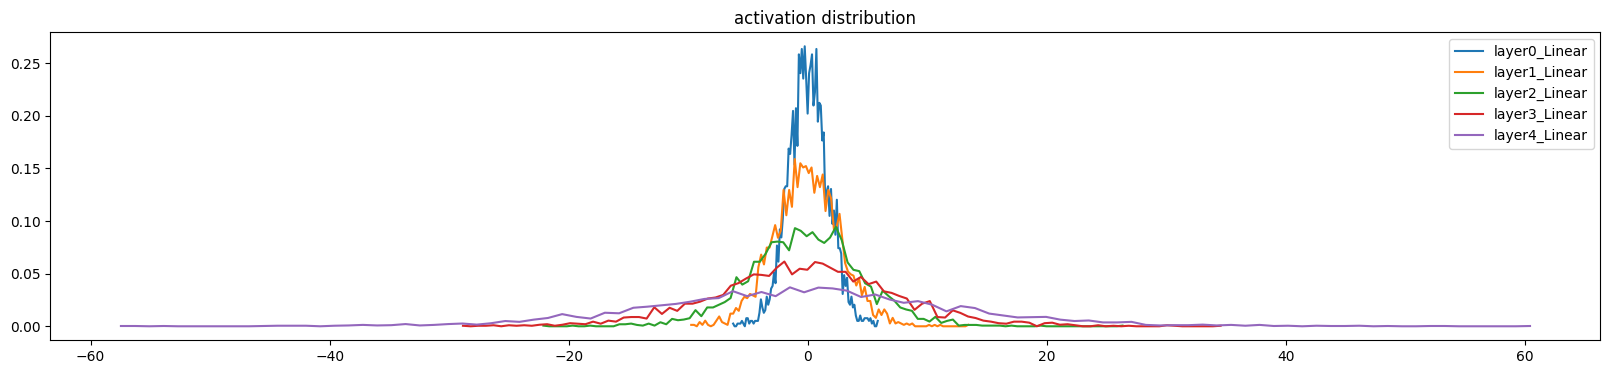

In [26]:
plot_out(layers, Linear)

layer 0 (    Linear): mean -0.00, std 0.00
layer 1 (    Linear): mean +0.00, std 0.00
layer 2 (    Linear): mean +0.00, std 0.00
layer 3 (    Linear): mean +0.00, std 0.00
layer 4 (    Linear): mean +0.00, std 0.00


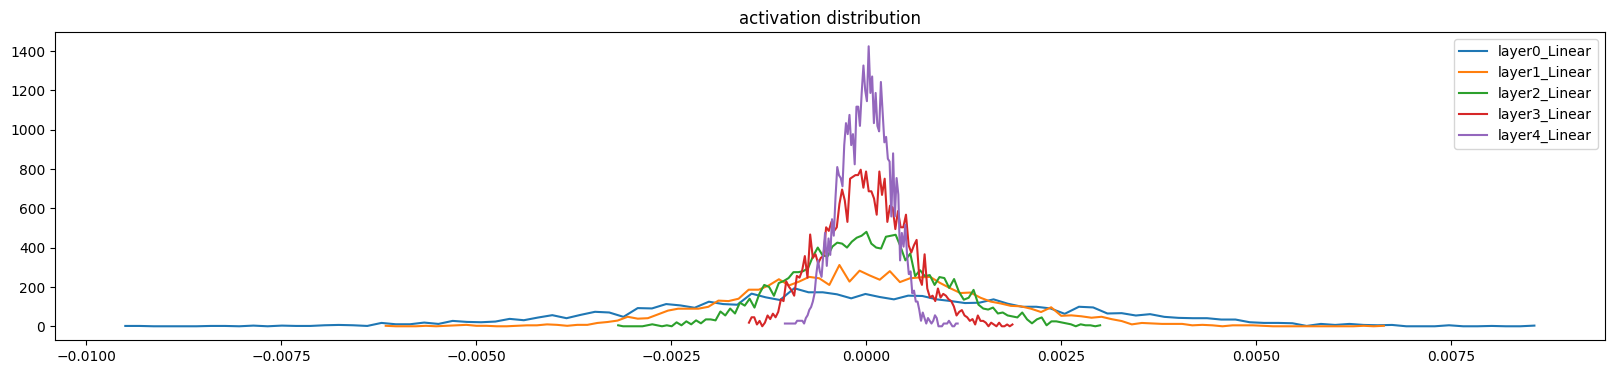

In [27]:
plot_out_grad(layers, Linear)

如果增益设置的比较大（对于纯线性层来说，默认应该gain是1，这里5/3（1.66就是比较大了）），设置为大于1的数字
+ 随着层数变深，线性层的输出值的方差在变大 同时输出的>0.97的值的比例越来越高（0附近的值越来越少，越来越向两边扩展了）
+ 但是梯度值随着层数变深，越来越收拢到0处附近了（即梯度在减小），而且每层的梯度分布差距很大
+ 因此，**神经网络中存在一种不对称性，如果全都是线性层，则层数越深，线性层的输出值会越大，而线性层的梯度会越小~**
+ **所以如果没有BN等归一化技术，对于深层的网络，参数的增益设置非常困难~**

如果增益设置的比较小，例如： 0.3，则就是相反的情况了，即：
+ 对于纯线性层网络，随着网络加深/层数变深, 线性层的输出值会越来越小，线性层的梯度会越来越大
+ 输出值会越来越小，一个小于1的小数一直连乘小于1的小数，值就是会越来越小
+ 梯度会越来越大，**因为梯度是反向传播的，所以越深的层乘以小数的次数越少，所以值越大~**

如果增益保持1，则效果就会正常
+ 不管多深层的输出值都基本符合标准正态分布
+ 不管多深层的梯度，基本所有层的梯度都呈现相同的分布

## 结论

在没有BN，Adam这些厉害的归一化技巧之前，想要设计一个深层的能够优秀训练的神经网络是一个很难的事情

必须要密切关注激活值和梯度的统计特性，才有可能训练出一个可用的神经网络

## 权重值可视化结果

46497
      0/ 200000: 3.2905
layer 1 (      Tanh): mean +0.01, std 0.74, saturated: 16.75%
layer 3 (      Tanh): mean -0.02, std 0.68, saturated: 7.03%
layer 5 (      Tanh): mean +0.01, std 0.67, saturated: 6.66%
layer 7 (      Tanh): mean +0.00, std 0.66, saturated: 6.56%
layer 9 (      Tanh): mean -0.01, std 0.66, saturated: 5.97%
layer 1 (      Tanh): mean -0.00, std 0.00
layer 3 (      Tanh): mean +0.00, std 0.00
layer 5 (      Tanh): mean -0.00, std 0.00
layer 7 (      Tanh): mean -0.00, std 0.00
layer 9 (      Tanh): mean +0.00, std 0.00


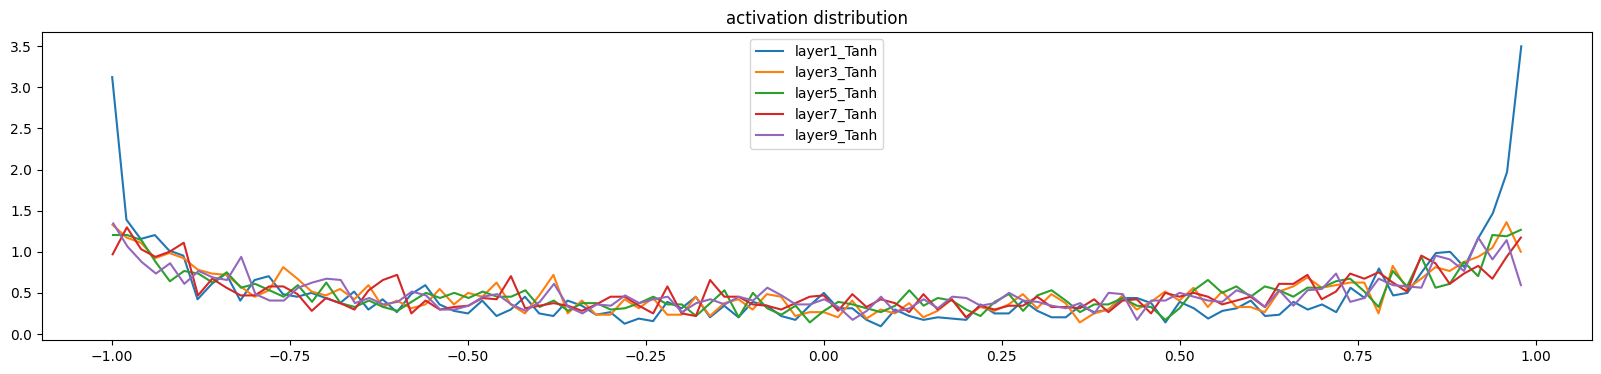

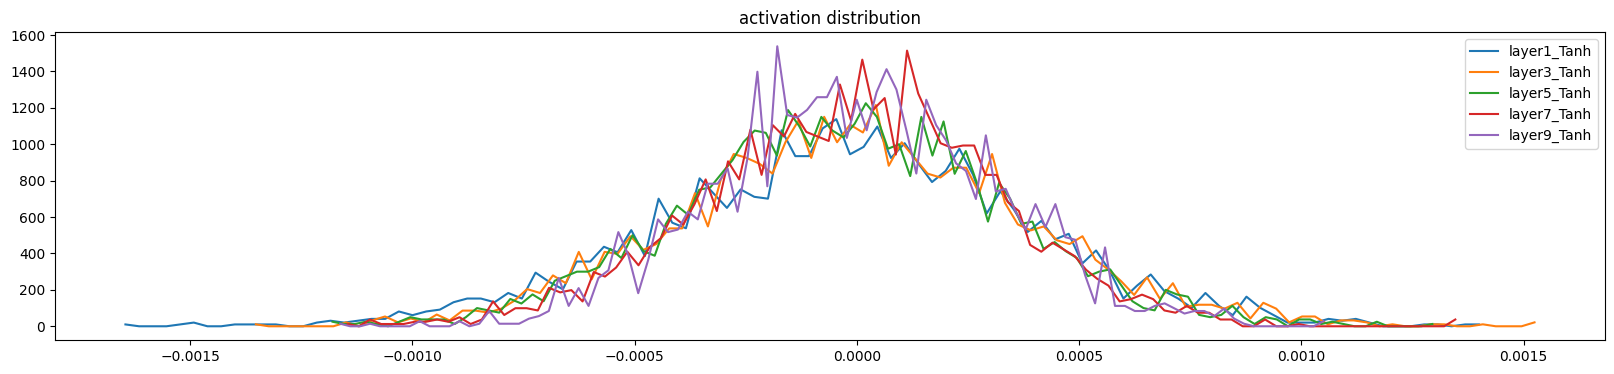

In [31]:
layers, parameters = run(5/3)
# 激活值分布
plot_out(layers)

# 激活值梯度分布
plot_out_grad(layers)

weight   (27, 10) | mean -0.000158 | std 1.491235e-03 | grad:data ratio 1.490156e-03
weight  (30, 100) | mean +0.000018 | std 1.286482e-03 | grad:data ratio 4.249351e-03
weight (100, 100) | mean +0.000016 | std 1.103418e-03 | grad:data ratio 6.545180e-03
weight (100, 100) | mean +0.000006 | std 9.388705e-04 | grad:data ratio 5.618114e-03
weight (100, 100) | mean -0.000006 | std 8.508635e-04 | grad:data ratio 5.080187e-03
weight (100, 100) | mean -0.000013 | std 7.886275e-04 | grad:data ratio 4.769949e-03
weight  (100, 27) | mean -0.000000 | std 2.205263e-02 | grad:data ratio 2.128915e+00


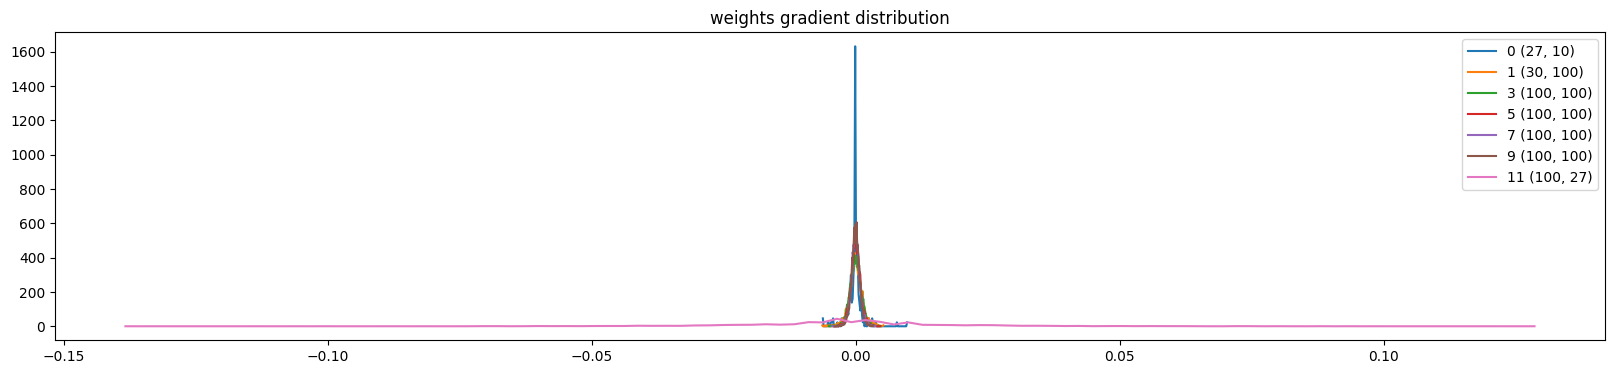

In [32]:
# 权重参数梯度分布
plot_w_grad(parameters)

虽然上面tanh层的激活值和梯度看起来还可以，但是整体的权重参数看起来有点不太对劲
+ 第一层的权重的梯度在0附近的太多了，这就是因为这是反向传播的最后一层，经历了11层的小数乘法，所以反向传播越深的层，梯度就会越小，但这并不是我们想看到的情况
+ 另外可以看到，这里的`grad/data`，
  + 除了最后一层是 2.0， 其余大概是 千分之一的差距比例，也就是说，在梯度更新的时候 `p.data += lr*p.grad` 这样得到的`p.data`更新的程度不过过于离谱
  + 所以最后一层这里有点问题，**从方差可以看到，最后一层的权重的梯度大概是前面层的10倍，所以最后一层的训练速度会是前面这些层的10倍**

对比下面运行1000步之后的结果
1. 运行1k步后，前向激活值的饱和度变高了（0步的饱和度是稳定在5%左右，1000步的饱和度则是稳定在10%左右），但是前向激活值的梯度每层的分布还是很稳定（不管是0步还是1000步每层的分布都比较一致，同时没有衰减到0，也没有爆炸）
2. 运行1k步之后，最后一层的权重的梯度和前面层没有在scale上相差10倍，基本是一个scale级别了

**运行1000步之后的结果**

46497
      0/ 200000: 3.2687
layer 1 (      Tanh): mean -0.02, std 0.75, saturated: 19.25%
layer 3 (      Tanh): mean -0.00, std 0.72, saturated: 10.56%
layer 5 (      Tanh): mean -0.03, std 0.72, saturated: 11.34%
layer 7 (      Tanh): mean +0.02, std 0.73, saturated: 11.81%
layer 9 (      Tanh): mean +0.03, std 0.71, saturated: 10.22%
layer 1 (      Tanh): mean +0.00, std 0.00
layer 3 (      Tanh): mean +0.00, std 0.00
layer 5 (      Tanh): mean -0.00, std 0.00
layer 7 (      Tanh): mean -0.00, std 0.00
layer 9 (      Tanh): mean -0.00, std 0.00


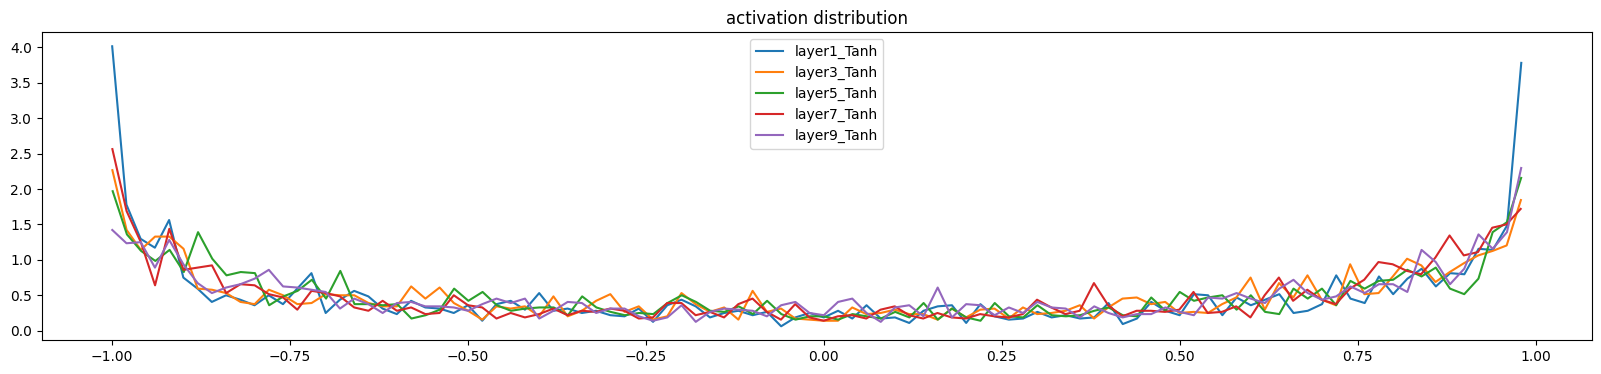

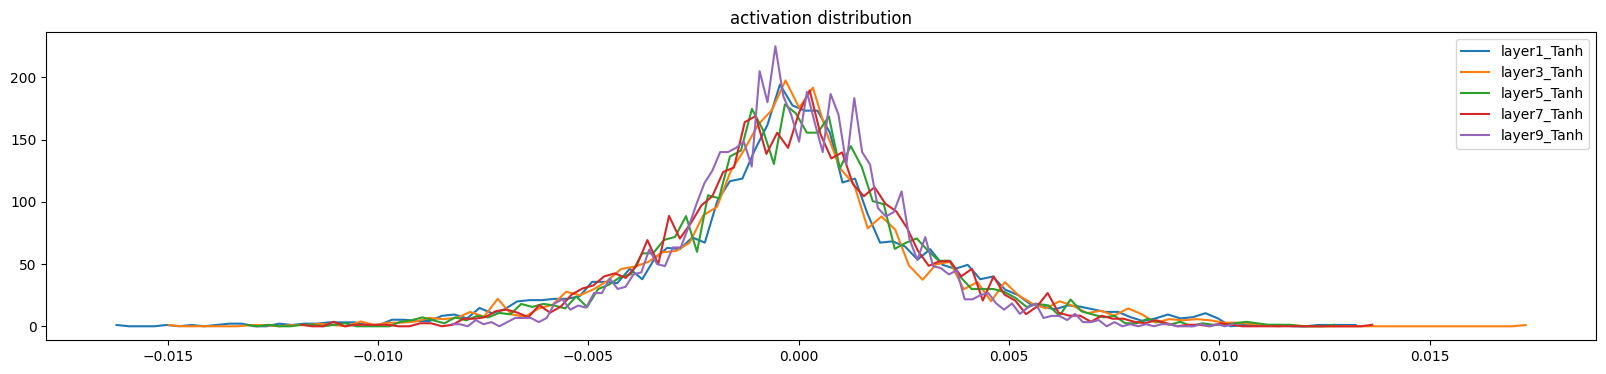

In [33]:
layers, parameters = run(5/3, normal_run=True)

# 激活值分布
plot_out(layers)

# 激活值梯度分布
plot_out_grad(layers)

46497
      0/ 200000: 3.3150
weight   (27, 10) | mean +0.001411 | std 1.257643e-02 | grad:data ratio 1.255436e-02
weight  (30, 100) | mean -0.000108 | std 9.566589e-03 | grad:data ratio 3.018491e-02
weight (100, 100) | mean -0.000080 | std 7.631421e-03 | grad:data ratio 4.493714e-02
weight (100, 100) | mean -0.000057 | std 6.720747e-03 | grad:data ratio 4.055434e-02
weight (100, 100) | mean -0.000028 | std 5.762687e-03 | grad:data ratio 3.413366e-02
weight (100, 100) | mean +0.000080 | std 4.834025e-03 | grad:data ratio 2.878728e-02
weight  (100, 27) | mean -0.000000 | std 2.024988e-02 | grad:data ratio 2.941972e-01


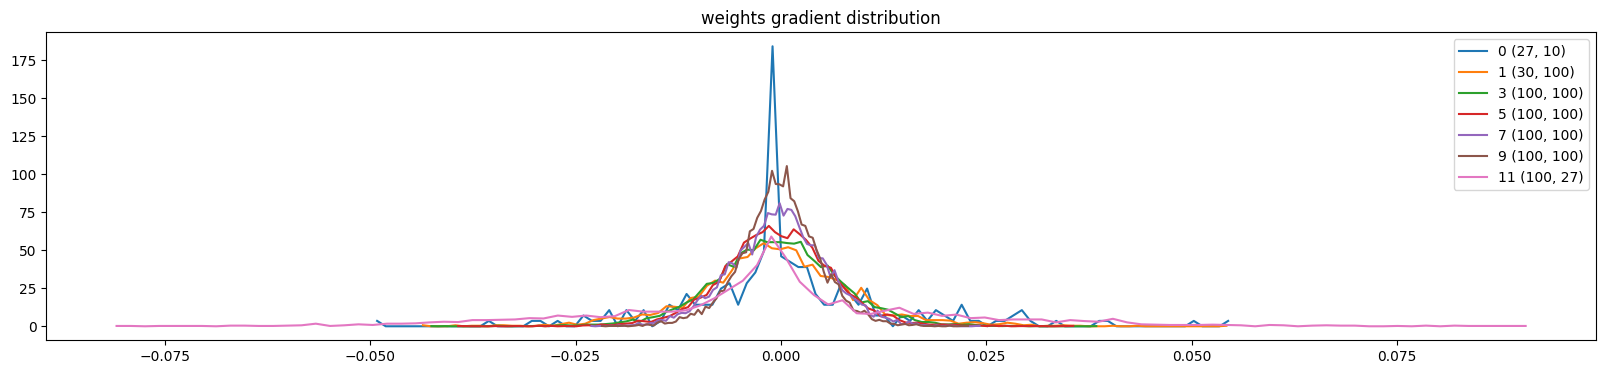

In [30]:
# 权重参数梯度分布
plot_w_grad(parameters)

## update:data可视化

除了 `grad:data`这个梯度数据比，实际上，在优化过程中，我们更关注的是`update:data`这个更新数据比，即：和lr相乘后的梯度:更新后的数据

In [44]:
def run_with_update(gain, normal_run = False, lr = 0.1):
    n_embd = 10 # the dimensionality of the character embedding vectors
    n_hidden = 100 # the number of neurons in the hidden layer of the MLP
    g = torch.Generator().manual_seed(2147483647) # for reproducibility
    
    C = torch.randn((vocab_size, n_embd),            generator=g)
    layers = [
      Linear(n_embd * block_size, n_hidden), Tanh(),
      Linear(           n_hidden, n_hidden), Tanh(),
      Linear(           n_hidden, n_hidden), Tanh(),
      Linear(           n_hidden, n_hidden), Tanh(),
      Linear(           n_hidden, n_hidden), Tanh(),
      Linear(           n_hidden, vocab_size),
    ]
    with torch.no_grad():
      layers[-1].weight *= 0.1
      for layer in layers[:-1]:
        if isinstance(layer, Linear):
          layer.weight *= gain    
    parameters = [C] + [p for layer in layers for p in layer.parameters()]
    print(sum(p.nelement() for p in parameters)) # number of parameters in total
    for p in parameters:
      p.requires_grad = True  

    max_steps = 200000
    batch_size = 32
    lossi = []
    ud = []        # update value
    
    for i in range(max_steps): 
      ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
      Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
      emb = C[Xb] # embed the characters into vectors
      x = emb.view(emb.shape[0], -1) # concatenate the vectors
      for layer in layers:
        x = layer(x)
      loss = F.cross_entropy(x, Yb) # loss function
      for layer in layers:
        layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
      for p in parameters:
        p.grad = None
      loss.backward()
      lr = lr if i < 150000 else 0.01 # step learning rate decay
      for p in parameters:
        p.data += -lr * p.grad
      if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
      lossi.append(loss.log10().item())
      with torch.no_grad():
          ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])
          # (每个参数的更新量的方差 / 每个参数数值的方差 )/log10()  所以如果是千分之一，那么这里的值就应该是 +3 -3左右
      if normal_run:
          if i >= 1000:
              break
      else:
          break # AFTER_DEBUG: would take out obviously to run full optimization
    return layers,parameters,ud

In [45]:
def plot_update_data_ratio(ud):
    plt.figure(figsize=(20, 4))
    legends = []
    for i,p in enumerate(parameters):
      if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])  # j其实是迭代次数， i是每个迭代里每个权重的 update：data
        legends.append('param %d' % i)
    plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
    plt.plot([0, len(ud)], [-1, -1], 'k')
    # len(ud)是1001，就是迭代了1000轮
    plt.legend(legends);

46497
      0/ 200000: 3.2982


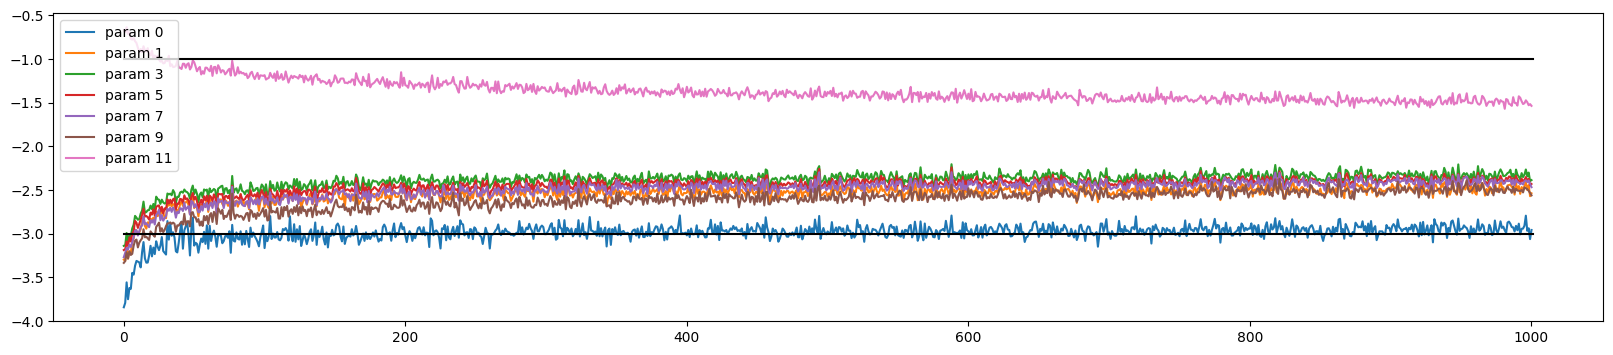

In [46]:
layers, parameters, ud = run_with_update(5/3, normal_run=True)
plot_update_data_ratio(ud)

+ 一般来说，`(权重更新值/权重数值).log10()= 1e-3`即：比例在千分之一附近比较合理，即上图的黑色直线，是界定的阈值线
+ 可以看到，上图中最后一层(最上面的粉色线)，值大概在1.0左右，也就是说每次更新的比例相当高，$10^{-1.0} = 0.1$, 每次更新权重的10%，这个更新幅度巨大~
  + 之所以最后一层看起来像个`outlier`(异常值), 是因为这层的权重在当时被人为缩小了 →  `layers[-1].weight *= 0.1` → 为了保证softmax输出不会那么自信，保证所有类别输出概率相等
  + 如果除开这0.1的降幅，其实这层的比值应该在 -2 附近，就不会显得和其它层离群的这么明显了
  + 不过随着训练的进行，这个更新比例又在逐渐下降稳定了
+ 一般老师的**训练经验**是：确保每层的这个更新比例不会大于-1，不会小于-3，即：**需要更新比例在 0.1~0.001之间，不能高于10%，但是不能低于 0.1%**
  + 如果低于 0.1%（-3），则说明训练效率太低了，更新不够快, 如下图所示（学习率从0.1 改成 0.001）：可以看到，大部分的更新比例都是 -5~-6之间，这样更新太慢了，十万分之一
  + 查看 更新量/数据 比例，也可以帮助我们判断学习率设置是否合理

In [42]:
w_num = 0
p_num = 0
for p in parameters:
    if p.ndim == 2:
        w_num += p.nelement() 
        p_num+=1
print(w_num, p_num)
print(len(ud))

45970 7
1001


46497
      0/ 200000: 3.3044


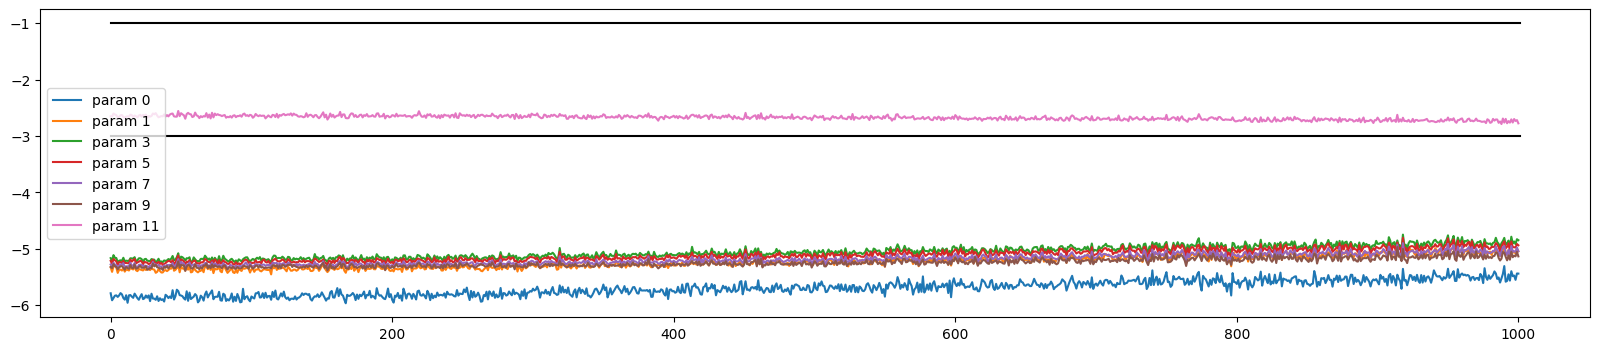

In [48]:
layers, parameters, ud = run_with_update(5/3, normal_run=True, lr = 0.001)
plot_update_data_ratio(ud)

# 加BN实现

# 其他

## 反向传播补充

```python
for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function
  
  # backward pass
  for layer in layers:
    layer.out.retain_grad() 
```
这里的`layer.out.retain_grad() `， 虽然在更早的代码里， `layer.out`不属于`parameters`, 没有被设置`p.requires_grad = True`

但是根据： [pytorch -> A Gentle Introduction to torch.autograd -> Exclusion from the DAG](https://docs.pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html#exclusion-from-the-dag)

The output tensor of an operation will require gradients even if only a single input tensor has `requires_grad=True`.

**在一个操作中，只要有一个输入设置了`requires_grad=True`，则这个操作的结果张量也会被设置为`requires_grad=True`**

```python
x = torch.rand(5, 5)
y = torch.rand(5, 5)
z = torch.rand((5, 5), requires_grad=True)

a = x + y
print(f"Does `a` require gradients?: {a.requires_grad}")
b = x + z
print(f"Does `b` require gradients?: {b.requires_grad}")
```
```bash
# output
Does `a` require gradients?: False
Does `b` require gradients?: True
```

[pytorch -> A Gentle Introduction to torch.autograd -> Background](https://docs.pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html#background)中提到的 video from 3Blue1Brown.

对应在B站的视频： [3Blue1Brown/中国官方账号-> 【官方双语】深度学习之反向传播算法 上/下 Part 3 ver 0.9 beta](https://www.bilibili.com/video/BV16x411V7Qg?spm_id_from=333.788.videopod.episodes&vd_source=1019ffdc843339404e9df6ae52ff9e77&p=2)

## __call__ vs __init__

在 Python 中，`__init__` 和 `__call__` 是两个非常重要的特殊方法（魔术方法），它们分别控制着**对象的创建初始化**和**对象的调用行为**。

简单来说：
*   **`__init__`** 决定了**如何创建一个对象**（当你使用 `MyClass()` 时触发）。
*   **`__call__`** 决定了**如何把一个对象当作函数来使用**（当你使用 `obj()` 时触发）。

| 对比维度 | `__init__` | `__call__` |
| :--- | :--- | :--- |
| **触发语法** | `obj = MyClass(args)` | `result = obj(args)` |
| **调用主体** | **类** (Class) | **实例对象** (Instance) |
| **核心目的** | 初始化对象状态，绑定初始属性 | 定义对象被当作函数调用时的具体行为 |
| **执行频率** | 对象创建时执行 **1 次** | 每次把对象当函数用时执行，可执行 **N 次** |

例如： 下面的代码中，
```python
a = Linear(3,4) # 这里调用的就是`init`, 基于类初始化一个实例
a(xxx)          # 这里调用的就是`call`, 直接调用实例
```

## tanh的gain为什么是5/3



Kaiming 初始化（也称为 He 初始化）中的 **gain** 是为了在使用特定非线性激活函数（如 tanh）时，保持信号在网络中前向传播时的方差大致不变。

对于 **tanh** 激活函数，PyTorch 等深度学习框架中使用的默认 **gain = 5/3 ≈ 1.6667**。这个值并不是通过严格的数学推导得出的最优值，而是基于一种**启发式近似**，其来源如下：

---

1. **Kaiming 初始化的基本思想**

Kaiming 初始化的目标是让每一层的输出方差大致等于输入方差（即保持信号幅度稳定）。对于一个线性变换后接激活函数 $ y = \phi(Wx) $，若 $ x $ 的元素独立同分布、均值为 0、方差为 $ \sigma_x^2 $，则希望：

$$
\mathrm{Var}(y) \approx \mathrm{Var}(x)
$$

为此，权重 $ W $ 的初始化方差应为：

$$
\mathrm{Var}(W) = \frac{\text{gain}^2}{n_{\text{in}}}
$$

其中 $ n_{\text{in}} $ 是输入维度，**gain** 取决于激活函数 $ \phi $。

---

2. **tanh 的 gain 为何是 5/3？**

tanh 在原点附近的泰勒展开为：

$$
\tanh(x) = x - \frac{x^3}{3} + \frac{2x^5}{15} - \cdots
$$

在输入较小（接近 0）时，tanh 近似为恒等函数（即 $\tanh(x) \approx x$），因此理想情况下 gain 应为 1。但实际训练中输入可能不是特别小，所以需要一个略大于 1 的增益来补偿 tanh 的“压缩”效应（因为 $|\tanh(x)| < |x|$ 对所有非零 $x$ 成立）。

启发式推导（来自原始 Kaiming 论文和 PyTorch 实现）：

- 假设输入 $ x \sim \mathcal{U}(-\sqrt{3}, \sqrt{3}) $，这样 $\mathrm{Var}(x) = 1$。
- 计算 $\mathbb{E}[\tanh^2(x)]$，然后令：
  $$
  \text{gain} = \frac{1}{\sqrt{\mathbb{E}[\tanh^2(x)]}}
  $$

但直接计算这个期望（如我们刚才用数值积分得到的）约为：

$$
\mathbb{E}[\tanh^2(x)] \approx 0.458 \quad \Rightarrow \quad \text{gain} \approx \frac{1}{\sqrt{0.458}} \approx 1.48
$$

这**并不等于** 5/3（≈1.6667）。

---

3. **那么 5/3 是怎么来的？**

实际上，**5/3 是一个经验选择**，最早出现在 **Glorot & Bengio (2010)** 的 Xavier 初始化论文中，用于 **sigmoid/tanh** 激活函数。

- Glorot 论文建议：对 tanh 使用 **uniform 初始化范围**为：
  $$
  W \sim \mathcal{U}\left( -\frac{\sqrt{6}}{\sqrt{n_{\text{in}} + n_{\text{out}}}}, \frac{\sqrt{6}}{\sqrt{n_{\text{in}} + n_{\text{out}}}} \right)
  $$
- 这相当于 gain = $\sqrt{4/3} \approx 1.1547$（因为 tanh 的导数在 0 处为 1，而 sigmoid 为 1/4，所以对 tanh 要放大）。

但在后续实践中（尤其是 PyTorch 的 `nn.init.calculate_gain`），开发者发现：

- 对 tanh 使用 **gain = 5/3** 在实验中表现良好；
- 这个值可能源于对 **tanh 导数平方期望**的粗略估计，或与 **ReLU 的 gain=√2** 类比而来的一种“安全放大”。

具体来说，**5/3 的来源可以追溯到以下近似**：

> **假设 tanh 的有效线性区域斜率约为 1，但为了补偿其饱和区的压缩，人为放大权重约 1.66 倍，使得梯度在反向传播时不至于过快衰减。**

PyTorch 官方文档明确说明：

> “The recommended gain value for tanh is 5/3, as suggested by [Bengio].”

尽管在 Bengio 的论文中并未严格推导出 5/3，但这一数值被广泛采纳为**经验最佳实践**。

---

4. **总结**

- **5/3 不是严格数学推导结果**，而是一个**经验性增益值**。
- 它旨在补偿 tanh 激活函数的非线性压缩效应，帮助维持前向/反向信号的方差。
- 数值积分表明理论最优 gain ≈ 1.48，但实践中 **5/3 ≈ 1.6667** 表现更好或更稳健。
- 因此，**5/3 是启发式选择，被深度学习社区广泛接受**。

如果你在实现自定义初始化，可以尝试使用理论值（≈1.48）或保留 5/3——后者更常见且兼容主流框架。
Kaiming 初始化（也称为 He 初始化）中的 **gain** 是为了在使用特定非线性激活函数（如 tanh）时，保持信号在网络中前向传播时的方差大致不变。

对于 **tanh** 激活函数，PyTorch 等深度学习框架中使用的默认 **gain = 5/3 ≈ 1.6667**。这个值并不是通过严格的数学推导得出的最优值，而是基于一种**启发式近似**